In [7]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import matplotlib.pyplot as plt
plt.rcParams['image.origin']='lower'
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle, Rectangle

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

import aefc_vortex
from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3, plot_data
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

fig_path = aefc_vortex.path/'figs'



# Make the nominal Fresnel model figure. 

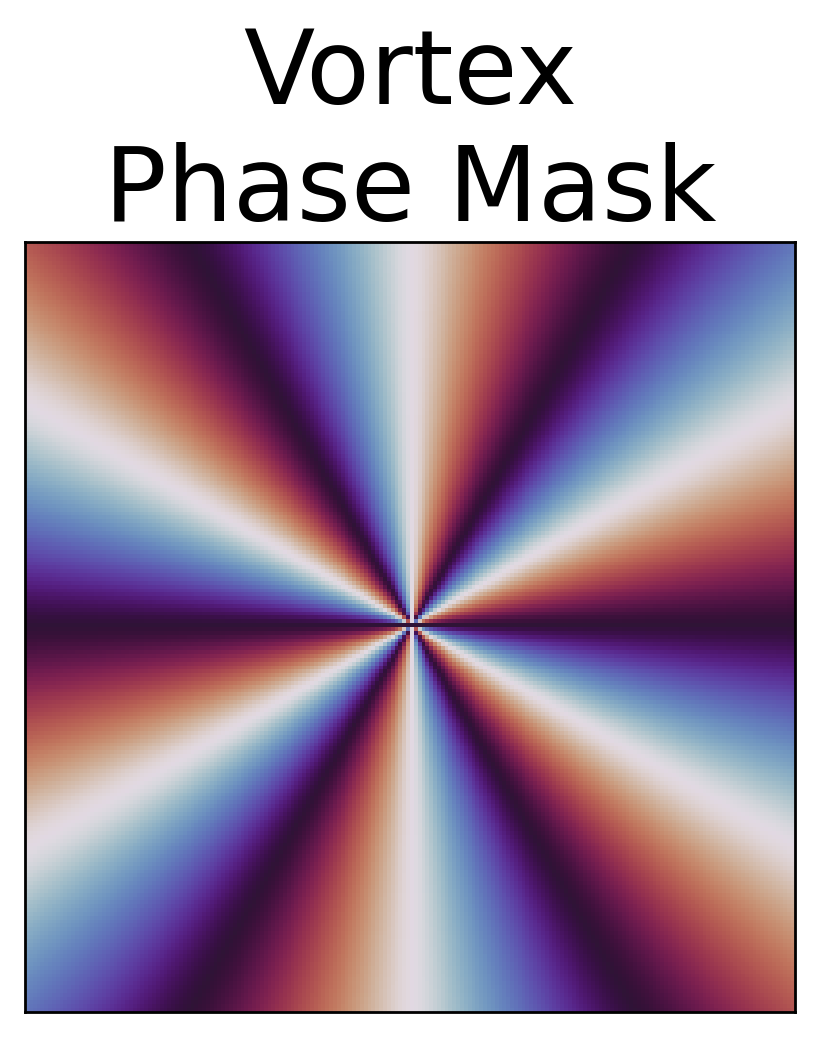

In [2]:
reload(fresnel)
reload(utils)
I = fresnel.CORO()

utils.imshow(
    [xp.angle(I.vortex_hres)],
    titles=['Vortex\nPhase Mask'],
    title_fzs=[30],
    cmaps=['twilight'],
    xticks=[[]], 
    yticks=[[]],
    show_cbars=[False],
    # cbar_labels=['Phase [radians]'],
    # cbar_label_rots=[-90],
    # cbar_label_pads=[15],
    npix=[200],
    dpi=250,
)


In [3]:
Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


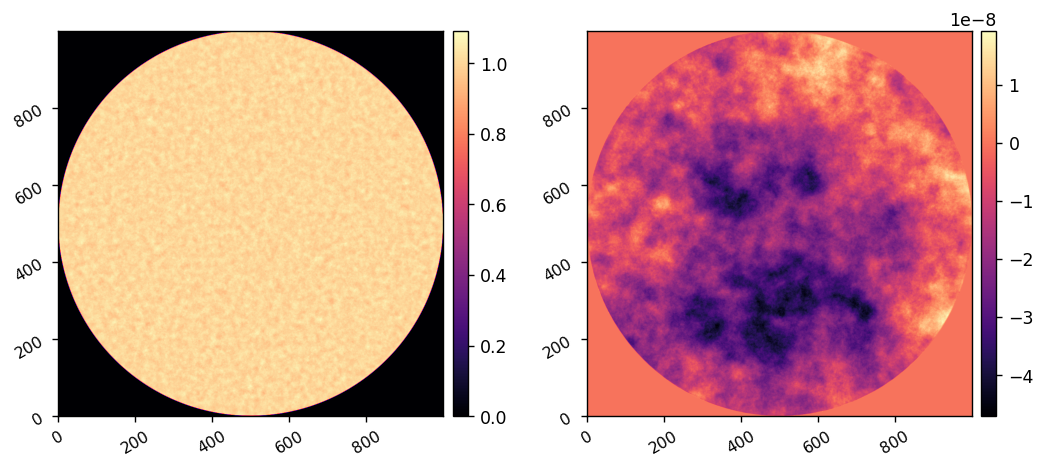

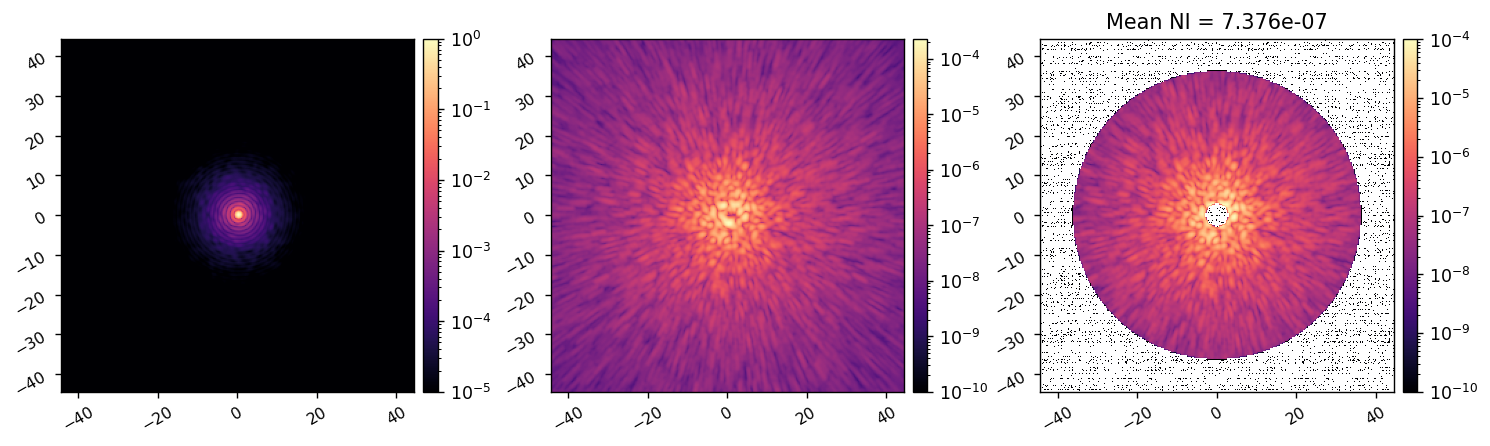

In [4]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
control_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.psf_pixelscale_lamDc, 
    irad=iwa, 
    orad=owa, 
    edge=None, 
    rotation=0,
)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)

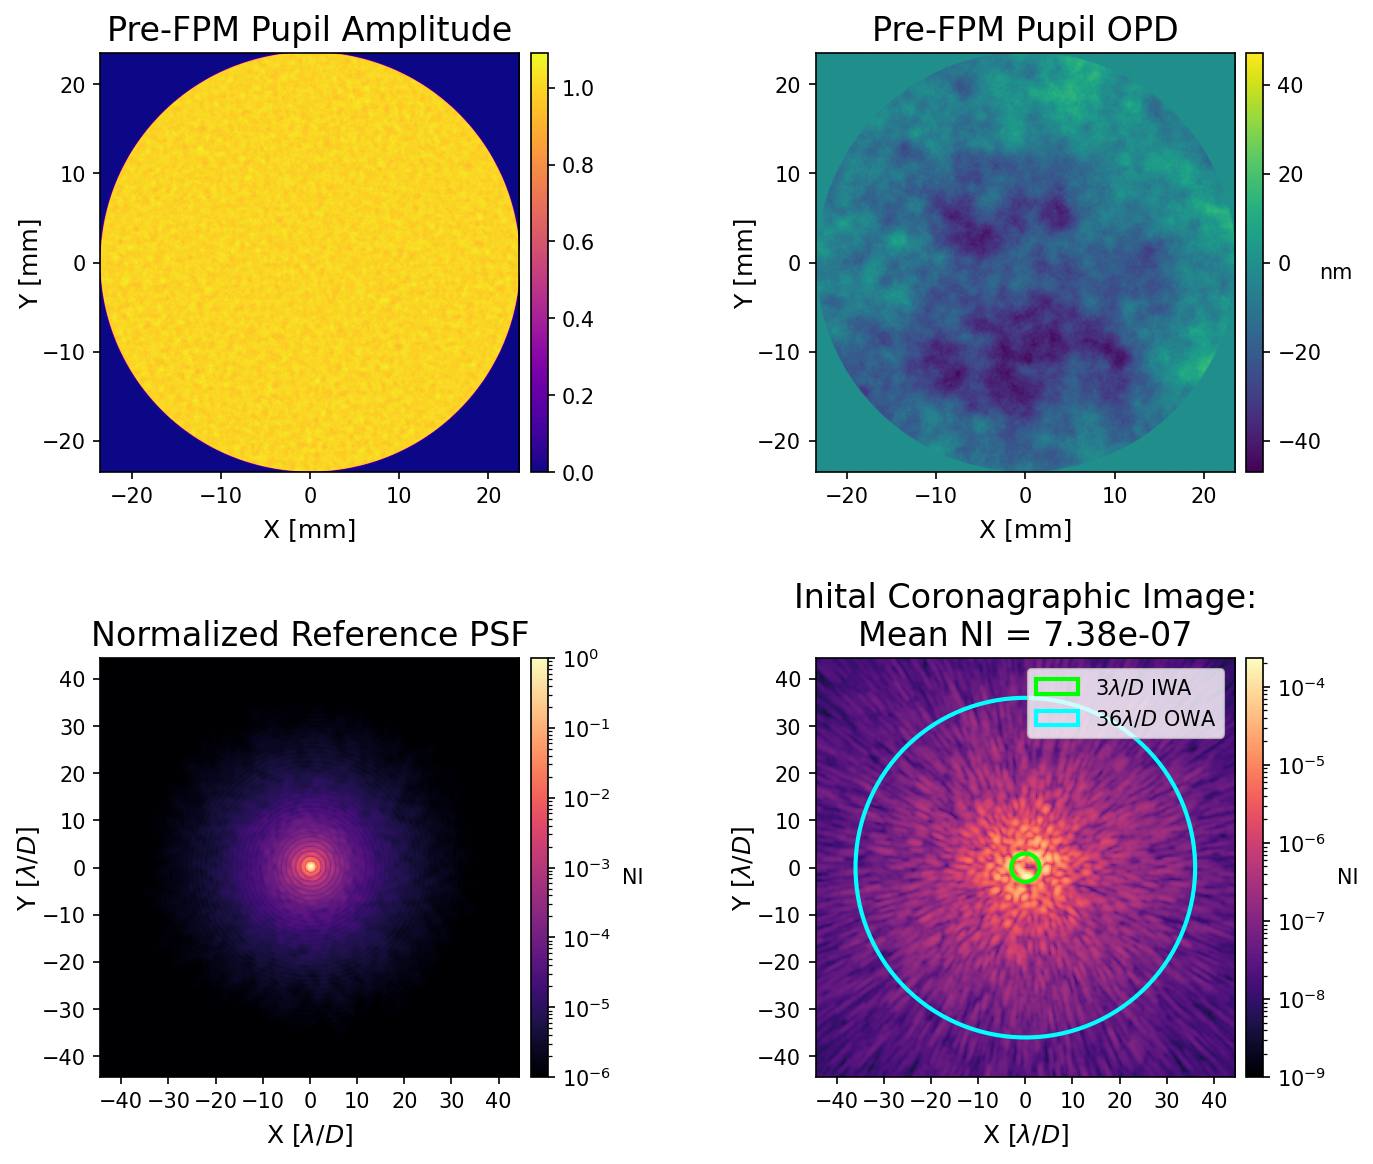

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,10), dpi=150)

ext = I.pupil_diam.to_value(u.mm)/2
pupil_extent = [-ext, ext, -ext, ext]

ext = I.psf_pixelscale_lamDc*I.npsf/2
psf_extent = [-ext, ext, -ext, ext]

patch1 = Circle((0,0), 3, fill=False, color='lime', linewidth=2.0, label='3$\lambda/D$ IWA')
patch2 = Circle((0,0), 36, fill=False, color='cyan', linewidth=2.0, label='36$\lambda/D$ OWA')

w = 0.475
tfs = 16
lfs = 12

ax = axs[0,0]
# AMP[~I.BAP_MASK] = xp.nan
im1 = ax.imshow( ensure_np_array(AMP), cmap='plasma', extent=pupil_extent)
# im1 = ax.imshow( ensure_np_array(AMP), cmap='plasma', extent=pupil_extent, norm=CenteredNorm(vcenter=1, halfrange=0.05, clip=False))
ax.set_title(f'Pre-FPM Pupil Amplitude', fontsize=tfs)
ax.set_xlabel('X [mm]', fontsize=lfs, labelpad=5)
ax.set_ylabel('Y [mm]', fontsize=lfs, labelpad=0)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im1, cax=cax)
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_position([0, 0, w, w]) # [left, bottom, width, height]

ax = axs[0,1]
im2 = ax.imshow( ensure_np_array(OPD)*1e9, cmap='viridis', norm=CenteredNorm(), extent=pupil_extent)
ax.set_title(f'Pre-FPM Pupil OPD', fontsize=tfs)
ax.set_xlabel('X [mm]', fontsize=lfs, labelpad=5)
ax.set_ylabel('Y [mm]', fontsize=lfs, labelpad=0)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im2, cax=cax,)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=7)
# ax.set_xticks([])
# ax.set_yticks([])
# ax[1].set_position([0.23, 0, w, w])

ax = axs[1,0]
im3 = ax.imshow( ensure_np_array(ref_psf), norm=LogNorm(vmax=1, vmin=1e-6), cmap='magma', extent=psf_extent)
ax.set_title(f'Normalized Reference PSF', fontsize=tfs)
ax.set_xlabel('X [$\lambda/D$]', fontsize=lfs, labelpad=5)
ax.set_ylabel('Y [$\lambda/D$]', fontsize=lfs, labelpad=0)
ax.set_xticks(np.arange(-40, 40.1, 10))
ax.set_yticks(np.arange(-40, 40.1, 10))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im3, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=10)
# ax[2].set_position([0.495, 0, w, w])

ax = axs[1,1]
im4 = ax.imshow( ensure_np_array(ref_coro_im), norm=LogNorm(vmin=1e-9), cmap='magma', extent=psf_extent)
ax.set_title(f'Inital Coronagraphic Image:\nMean NI = {mean_ni0:.2e}', fontsize=tfs)
ax.set_xlabel('X [$\lambda/D$]', fontsize=lfs, labelpad=5)
ax.set_ylabel('Y [$\lambda/D$]', fontsize=lfs, labelpad=0)
ax.set_xticks(np.arange(-40, 40.1, 10))
ax.set_yticks(np.arange(-40, 40.1, 10))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im4, cax=cax,)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=10)
ax.add_patch(patch1)
ax.add_patch(patch2)
ax.legend()

# ax[3].set_position([0.75, 0, w, w])

plt.subplots_adjust(
    wspace=0.6,
    hspace=0.1,
)
fig.savefig(fig_path/'sim_fresnel_model.pdf', format='pdf', bbox_inches="tight")

# Make the figure for broadband aEFC and EFC without model errors. 

In [13]:

efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_efc_run_without_ME.pkl')
aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_aefc_run_without_ME.pkl')


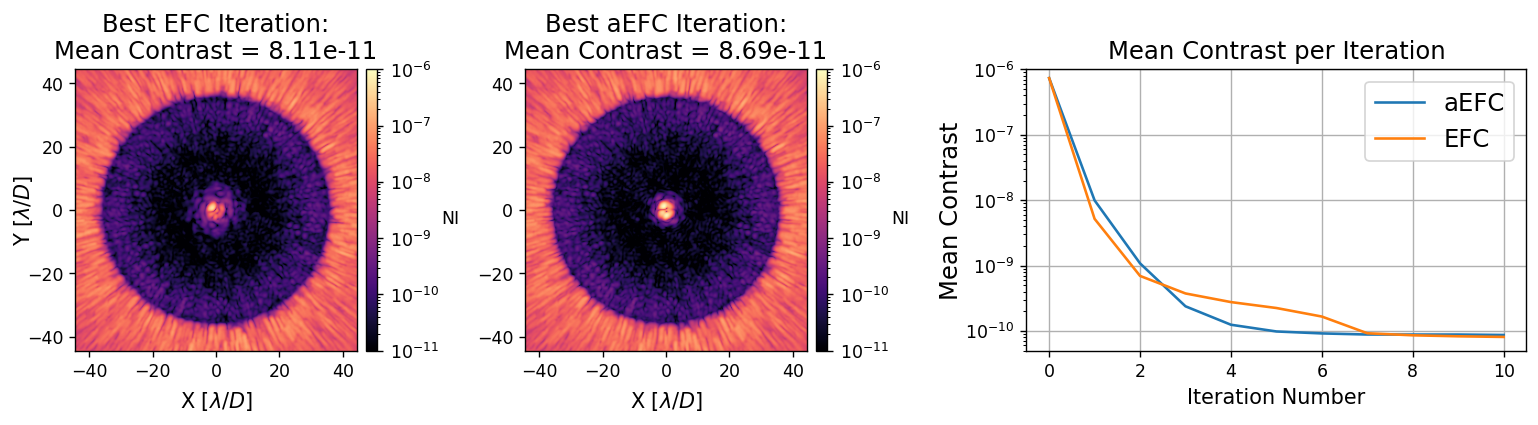

In [15]:
efc_ims = ensure_np_array( xp.array(efc_data['images']) ) 
aefc_ims = ensure_np_array( xp.array(aefc_data['images']) ) 

im1vmin=1e-11 
im1vmax=1e-6 
im2vmin=1e-11
im2vmax=1e-6 
vmin=5e-11 
vmax=1e-6
xticks=None

# print(type(control_mask))
Nitr_efc = efc_ims.shape[0]
Nitr_aefc = efc_ims.shape[0]

control_mask = ensure_np_array( efc_data['control_mask'] )
npsf = efc_ims.shape[1]
psf_pixelscale_lamD = efc_data['pixelscale']

mean_nis_efc = np.mean(efc_ims[:,control_mask], axis=1)
ibest_efc = np.argmin(mean_nis_efc)
best_efc_im = ensure_np_array(efc_data['images'][ibest_efc])
mean_nis_aefc = np.mean(aefc_ims[:,control_mask], axis=1)
ibest_aefc = np.argmin(mean_nis_aefc)
best_aefc_im = ensure_np_array(aefc_data['images'][ibest_aefc])

fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(16,9), dpi=125, gridspec_kw={'width_ratios': [1, 1, 1], })
ext = psf_pixelscale_lamD*npsf/2
extent = [-ext, ext, -ext, ext]

im1 = ax[0].imshow(best_efc_im, norm=LogNorm(vmax=im1vmax, vmin=im1vmin), cmap='magma', extent=extent)
ax[0].set_title(f'Best EFC Iteration:\nMean Contrast = {mean_nis_efc[ibest_efc]:.2e}', fontsize=14)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im1, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=7)
ax[0].set_position([0, 0.3, 0.25, 0.25]) # [left, bottom, width, height]

im2 = ax[1].imshow( best_aefc_im, norm=LogNorm(vmax=im2vmax, vmin=im2vmin), cmap='magma', extent=extent)
ax[1].set_title(f'Best aEFC Iteration:\nMean Contrast = {mean_nis_aefc[ibest_aefc]:.2e}', fontsize=14)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im2, cax=cax,)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=7)
ax[1].set_position([0.225, 0.3, 0.25, 0.25])

ax[0].set_ylabel('Y [$\lambda/D$]', fontsize=12, labelpad=-5)
ax[0].set_xlabel('X [$\lambda/D$]', fontsize=12, labelpad=5)
ax[1].set_xlabel('X [$\lambda/D$]', fontsize=12, labelpad=5)

ax[2].set_title('Mean Contrast per Iteration', fontsize=14)
ax[2].semilogy(mean_nis_aefc, label='aEFC')
ax[2].semilogy(mean_nis_efc, label='EFC')
ax[2].grid()
ax[2].set_xlabel('Iteration Number', fontsize=12, )
ax[2].set_ylabel('Mean Contrast', fontsize=14, labelpad=1)
ax[2].set_ylim([vmin, vmax])
xticks = np.arange(0, Nitr_efc,2) if xticks is None else xticks
ax[2].set_xticks(xticks)
ax[2].legend(loc='upper right', fontsize=14)
ax[2].set_position([0.525, 0.3, 0.25, 0.25])

fig.savefig(fig_path/'sim_bb.pdf', format='pdf', bbox_inches="tight")

# Make the figure for broadband aEFC and EFC with model errors. 

In [ ]:

efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_efc_run_with_ME_2.pkl')
aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250310}_aefc_run_with_ME.pkl')


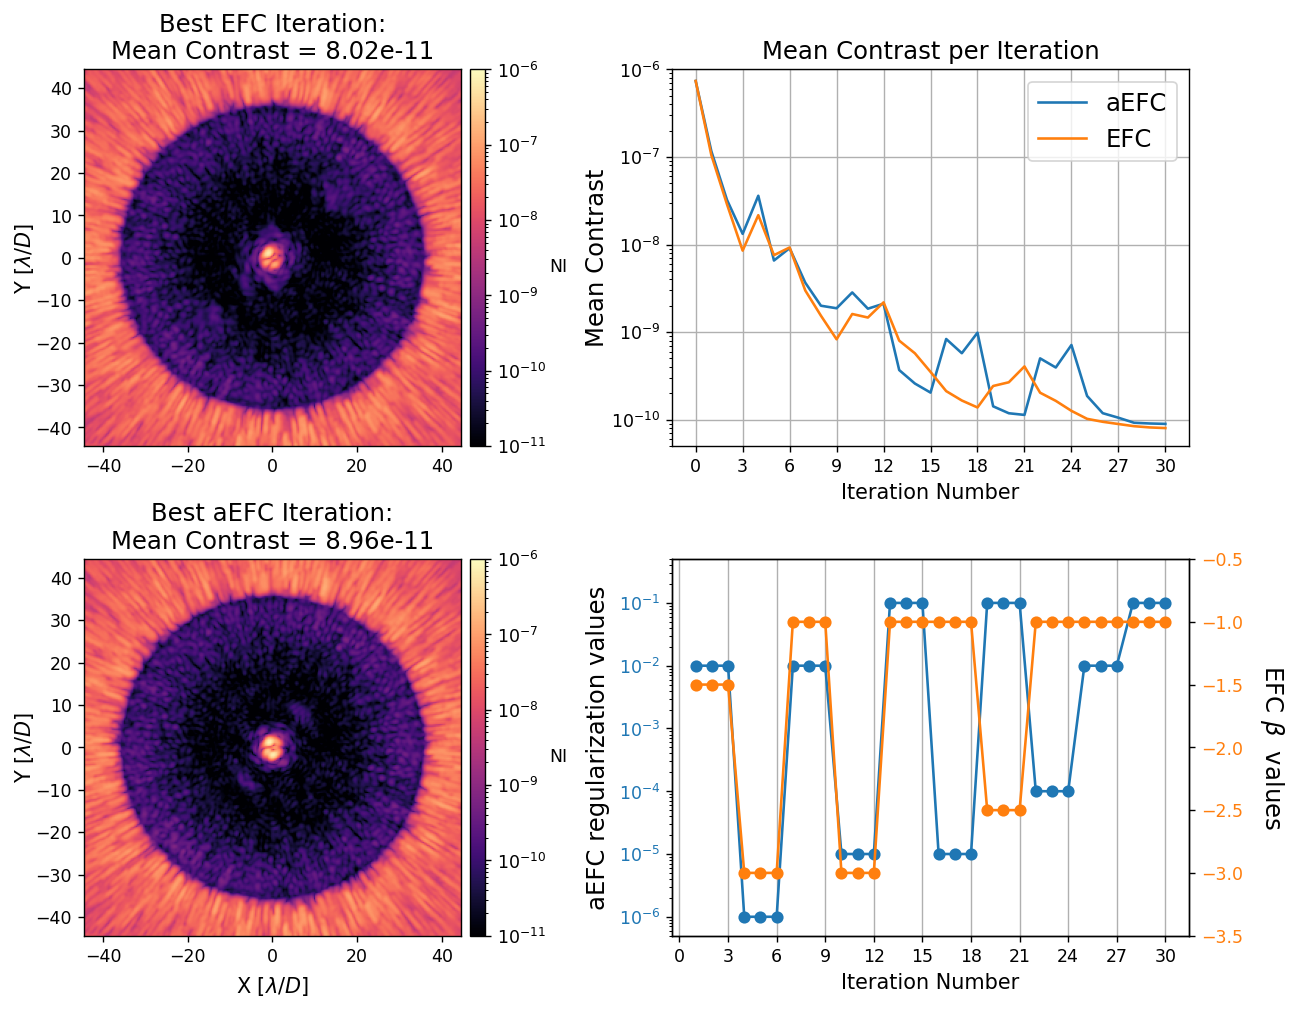

In [17]:
efc_ims = ensure_np_array( xp.array(efc_data['images']) ) 
aefc_ims = ensure_np_array( xp.array(aefc_data['images']) ) 

im1vmin=1e-11 
im1vmax=1e-6 
im2vmin=1e-11 
im2vmax=1e-6 
vmin=5e-11
vmax=1e-6
xticks=np.linspace(0,30,11)

# print(type(control_mask))
Nitr_efc = efc_ims.shape[0]
Nitr_aefc = efc_ims.shape[0]

control_mask = ensure_np_array( efc_data['control_mask'] )
npsf = efc_ims.shape[1]
psf_pixelscale_lamD = efc_data['pixelscale']

mean_nis_efc = np.mean(efc_ims[:,control_mask], axis=1)
ibest_efc = np.argmin(mean_nis_efc)
best_efc_im = ensure_np_array(efc_data['images'][ibest_efc])
mean_nis_aefc = np.mean(aefc_ims[:,control_mask], axis=1)
ibest_aefc = np.argmin(mean_nis_aefc)
best_aefc_im = ensure_np_array(aefc_data['images'][ibest_aefc])

aefc_reg_conds = aefc_data['reg_conds']
efc_reg_conds = efc_data['reg_conds']

fig,ax = plt.subplots(nrows=2, ncols=2, figsize=(12,9), dpi=125,)
ext = psf_pixelscale_lamD*npsf/2
extent = [-ext, ext, -ext, ext]

im1 = ax[0,0].imshow(best_efc_im, norm=LogNorm(vmax=im1vmax, vmin=im1vmin), cmap='magma', extent=extent)
ax[0,0].set_title(f'Best EFC Iteration:\nMean Contrast = {mean_nis_efc[ibest_efc]:.2e}', fontsize=14)
divider = make_axes_locatable(ax[0,0])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im1, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=7)
# ax[0,0].set_position([0, 0.3, 0.25, 0.25]) # [left, bottom, width, height]

im2 = ax[1,0].imshow( best_aefc_im, norm=LogNorm(vmax=im2vmax, vmin=im2vmin), cmap='magma', extent=extent)
ax[1,0].set_title(f'Best aEFC Iteration:\nMean Contrast = {mean_nis_aefc[ibest_aefc]:.2e}', fontsize=14)
divider = make_axes_locatable(ax[1,0])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im2, cax=cax,)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=7)
# ax[1,0].set_position([0.225, 0.3, 0.25, 0.25])

ax[0,0].set_ylabel('Y [$\lambda/D$]', fontsize=12, labelpad=0)
ax[1,0].set_ylabel('Y [$\lambda/D$]', fontsize=12, labelpad=0)
ax[1,0].set_xlabel('X [$\lambda/D$]', fontsize=12, labelpad=5)

xticks = np.arange(0, Nitr_efc,2) if xticks is None else xticks

ax[0,1].semilogy(mean_nis_aefc, label='aEFC')
ax[0,1].semilogy(mean_nis_efc, label='EFC')
ax[0,1].set_title('Mean Contrast per Iteration', fontsize=14)
ax[0,1].grid()
ax[0,1].set_xlabel('Iteration Number', fontsize=12, )
ax[0,1].set_ylabel('Mean Contrast', fontsize=14, labelpad=1)
ax[0,1].set_ylim([vmin, vmax])
ax[0,1].set_xticks(xticks)
ax[0,1].legend(loc='upper right', fontsize=14)
# ax[2].set_position([0.525, 0.3, 0.25, 0.25])

ax1 = ax[1,1]
ax1.semilogy(np.linspace(1, Nitr_aefc-1, Nitr_aefc-1), aefc_reg_conds, '-o', label='aEFC', )
ax1.set_ylabel('aEFC regularization values', fontsize=14, labelpad=5,)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim([5e-7, 5e-1])
ax2 = ax1.twinx()
ax2.plot(np.linspace(1, Nitr_efc-1, Nitr_efc-1), efc_reg_conds, '-o', color='#ff7f0e',)
ax2.set_ylabel('EFC $\\beta$  values', fontsize=14, rotation=-90, labelpad = 25)
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim([-3.5, -0.5])
ax2.set_xticks(xticks)
ax[1,1].grid(axis='x')
# ax[1,1].legend()

ax1.set_xlabel('Iteration Number', fontsize=12, )

plt.subplots_adjust(wspace=0.25, hspace=0.3)

fig.savefig(fig_path/'sim_bb_with_me.pdf', format='pdf', bbox_inches="tight")